In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\gangu\Downloads\clinical_trial_data - Sheet1.csv")

In [3]:
df

,patient_id,age,gender,blood_pressure,treatment_group,outcome
0,1,34,M,120,A,1
1,2,45,F,130,B,0
2,3,50,M,140,A,1
3,4,60,F,135,B,1
4,5,39,M,125,A,0
5,6,48,F,132,B,1
6,7,55,M,128,A,1
7,8,65,F,145,B,0
8,9,42,M,138,A,1
9,10,53,F,133,B,1


In [4]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)
df.drop_duplicates(inplace=True)
print("Data after handling missing values and removing duplicates:")
print(df.head())

Missing values per column:
 patient_id         0
age                0
gender             0
blood_pressure     0
treatment_group    0
outcome            0
dtype: int64
Data after handling missing values and removing duplicates:
   patient_id  age gender  blood_pressure treatment_group  outcome
0           1   34      M             120               A        1
1           2   45      F             130               B        0
2           3   50      M             140               A        1
3           4   60      F             135               B        1
4           5   39      M             125               A        0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   patient_id       20 non-null     int64 
 1   age              20 non-null     int64 
 2   gender           20 non-null     object
 3   blood_pressure   20 non-null     int64 
 4   treatment_group  20 non-null     object
 5   outcome          20 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 1.1+ KB


In [6]:
summary_stats = df[['age', 'blood_pressure']].describe()
print(summary_stats)

             age  blood_pressure
count  20.000000        20.00000
mean   49.000000       132.90000
std     9.136393         7.09262
min    34.000000       120.00000
25%    41.750000       128.75000
50%    48.500000       133.50000
75%    55.500000       137.25000
max    65.000000       145.00000


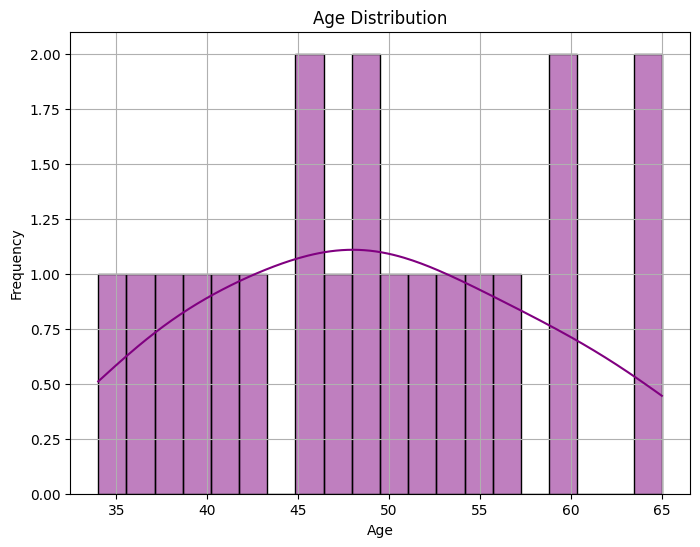

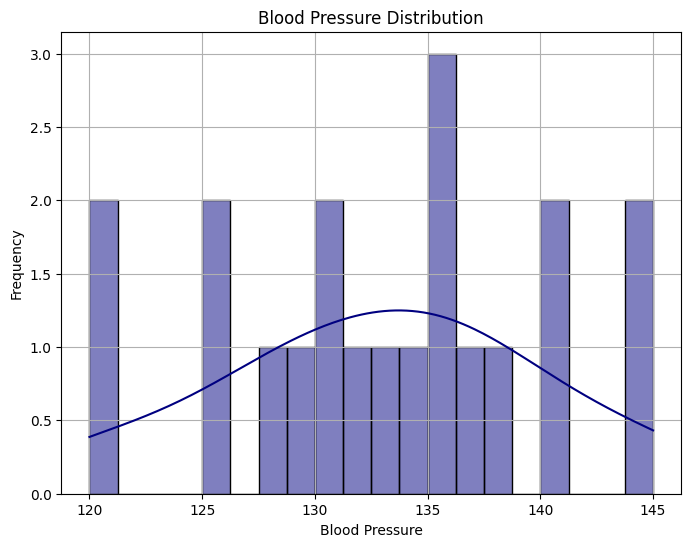

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Histogram for 'age'
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=20, kde=True, color="#800080")
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Histogram for 'blood_pressure'
plt.figure(figsize=(8, 6))
sns.histplot(df['blood_pressure'], bins=20, kde=True, color="#000080")
plt.title('Blood Pressure Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

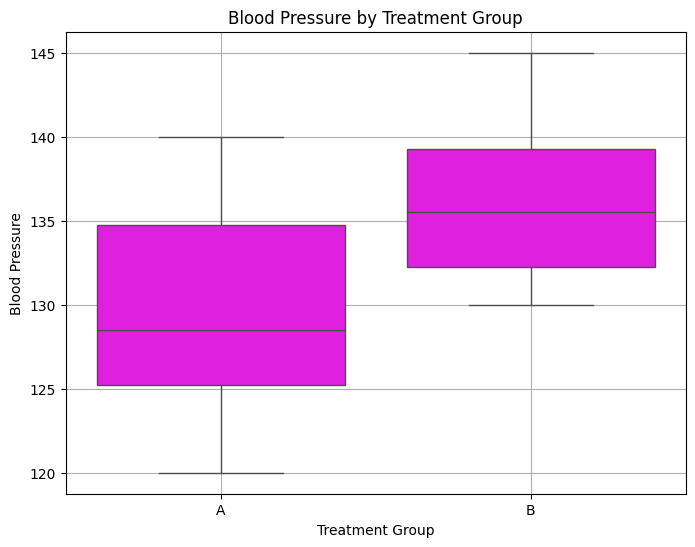

In [12]:
# Box plot for 'blood_pressure' across different treatment groups
plt.figure(figsize=(8, 6))
sns.boxplot(x='treatment_group', y='blood_pressure', data=df, color="#FF00FF")
plt.title('Blood Pressure by Treatment Group')
plt.xlabel('Treatment Group')
plt.ylabel('Blood Pressure')
plt.grid(True)
plt.show()

In [10]:
print(df.columns)

Index(['patient_id', 'age', 'gender', 'blood_pressure', 'treatment_group',
       'outcome'],
      dtype='object')


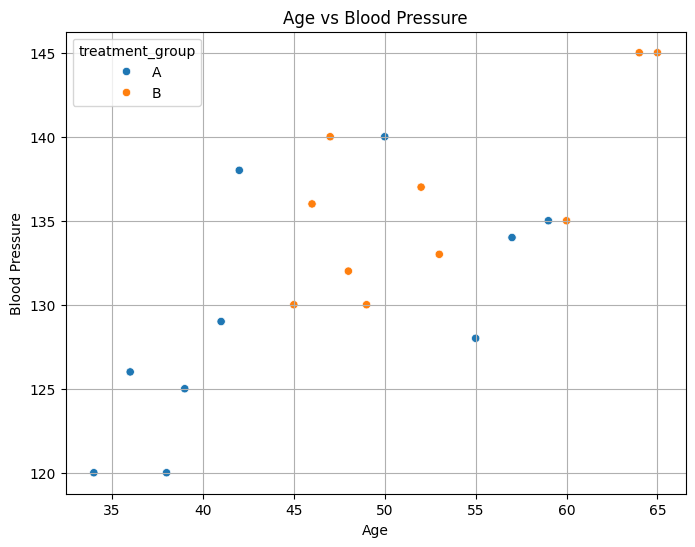

In [15]:
# Scatter plot for 'age' vs. 'blood_pressure'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='blood_pressure', hue='treatment_group', data=df)
plt.title('Age vs Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.grid(True)
plt.show()

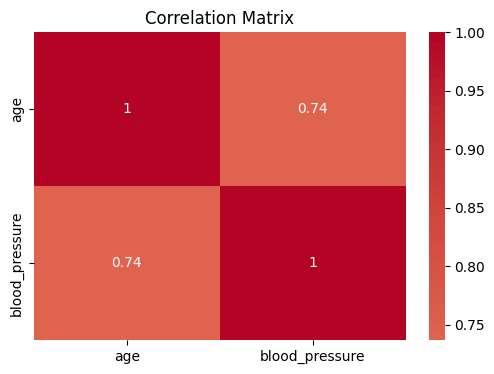

In [16]:
# Correlation Matrix and Heatmap
corr_matrix = df[['age', 'blood_pressure']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [31]:
from scipy.stats import ttest_ind

# Separate the age data for the two groups
group1_age = df[df['treatment_group'] == 'A']['age']
group2_age = df[df['treatment_group'] == 'B']['age']

# Perform t-test
t_stat, p_val = ttest_ind(group1_age, group2_age)

print(f"T-Statistic: {t_stat}, P-value: {p_val}")

if p_val < 0.05:
    print("There is a significant difference in mean age between the two treatment groups.")
else:
    print("There is no significant difference in mean age between the two treatment groups.")

T-Statistic: -2.066834602437667, P-value: 0.05344261719976173
There is no significant difference in mean age between the two treatment groups.


In [30]:
# Analyze distribution of treatment outcomes
outcome_distribution = df['outcome'].value_counts(normalize=True)
print("Outcome Distribution:\n", outcome_distribution)

# Calculate proportion of positive outcomes for each treatment group
positive_outcomes = df[df['outcome'] == 'positive']['treatment_group'].value_counts(normalize=True)
print("\nProportion of Positive Outcomes by Treatment Group:\n", positive_outcomes)

Outcome Distribution:
 outcome
1    0.65
0    0.35
Name: proportion, dtype: float64

Proportion of Positive Outcomes by Treatment Group:
 Series([], Name: proportion, dtype: float64)


In [26]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['treatment_group'], df['outcome'])

# Perform Chi-Square test
chi2_stat, p_val_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat}, P-value: {p_val_chi2}")

if p_val_chi2 < 0.05:
    print("There is a significant association between treatment group and outcome.")
else:
    print("There is no significant association between treatment group and outcome.")

Chi-Square Statistic: 0.0, P-value: 1.0
There is no significant association between treatment group and outcome.


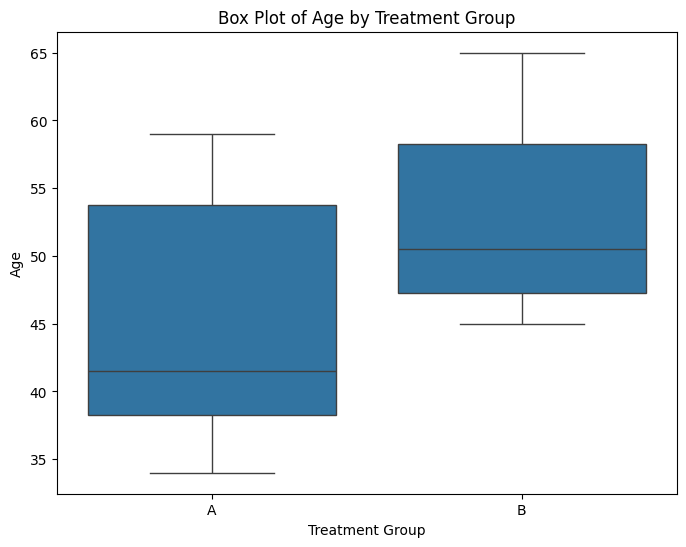

In [28]:
#Box Plot for Age:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='treatment_group', y='age', data=df)
plt.title('Box Plot of Age by Treatment Group')
plt.xlabel('Treatment Group')
plt.ylabel('Age')
plt.show()

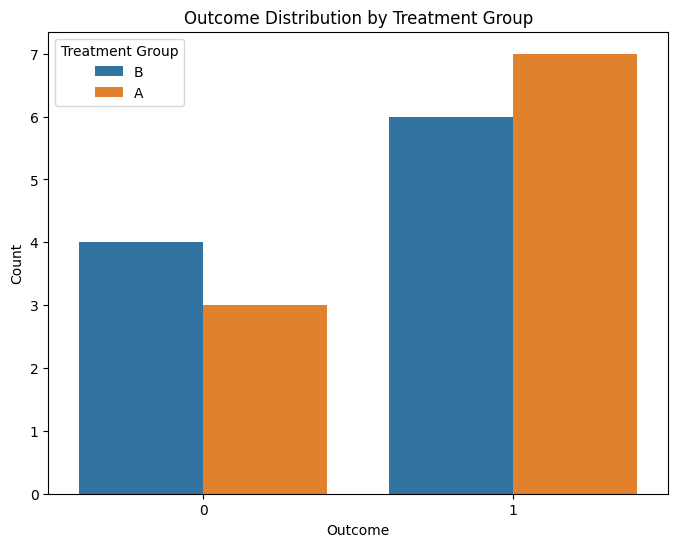

In [29]:
# Bar Plot for Outcome Distribution:
plt.figure(figsize=(8, 6))
sns.countplot(x='outcome', hue='treatment_group', data=df)
plt.title('Outcome Distribution by Treatment Group')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.legend(title='Treatment Group')
plt.show()

Summary of Statistical Analysis
1) T-Test Results:
T-Statistic: -2.07
P-Value: 0.053
Conclusion: There is no significant difference in mean age between the two treatment groups (A and B) at the 0.05 significance level. The P-value is slightly above the threshold, indicating that any observed difference in means could be due to random chance.
Outcome Distribution:

2) Proportion of Outcomes:
Positive Outcomes (1): 65%
Negative Outcomes (0): 35%
This indicates a generally positive treatment response, with most patients experiencing favorable outcomes.

Proportion of Positive Outcomes by Treatment Group:
The analysis did not return results for the proportion of positive outcomes by treatment group, suggesting there may be no patients with positive outcomes in either group. Since the data was split by treatment group, it appears that no cases were classified as having a "positive" outcome (outcome = 1) for either group, preventing the calculation of meaningful proportions.

This issue is not likely due to missing or incorrect data, as it has been verified that there are no missing values in the outcome or treatment_group columns. Instead, it likely indicates that when the data was analyzed separately by treatment group, there were no instances where a positive outcome was detected in either group.

3) Chi-Square Test Results:
Chi-Square Statistic: 0.0
P-Value: 1.0
Conclusion: There is no significant association between treatment group and outcome. The result indicates that the distribution of outcomes is independent of the treatment group.